In [1]:
# 导入需要的算法库和模块
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 导入决策树模块，该模块下可引用DecisionTreeClassifier决策树分类器
from sklearn import tree

# 导入红酒检测数据集
from sklearn.datasets import load_wine

# 导入数据集划分对象
from sklearn.model_selection import train_test_split

# 基本参数设置
plt.rcParams['font.sans-serif']=['Simhei']
plt.rcParams['axes.unicode_minus']=False

In [2]:
from IPython.core.interactiveshell import InteractiveShell # 这个对象设置所有行全部输出

# 设置该对象ast_node_interactivity属性的值为all，表示在notebook下每一行有输出的代码全部输出运算结果
InteractiveShell.ast_node_interactivity = "all" 

In [3]:
# 加载sklearn自带红酒检测数据集
wine = load_wine()

# 获取数据集
wine.data

# 获取数据集形状
wine.data.shape

# 获取标签
wine.target

array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
        1.065e+03],
       [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
        1.050e+03],
       [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
        1.185e+03],
       ...,
       [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
        8.350e+02],
       [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
        8.400e+02],
       [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
        5.600e+02]], shape=(178, 13))

(178, 13)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

In [4]:
# 拼接data和target，轴1方向拼接（列方向）
wine_pd = pd.concat([pd.DataFrame(wine.data),pd.DataFrame(wine.target)],axis = 1).head()

# 展示数据：为标签字段添加列索引名称
wine.feature_names.append("类别")

# 设置标签的列索引名称
wine_pd.columns = wine.feature_names
wine_pd

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,类别
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [5]:
wine.feature_names

['alcohol',
 'malic_acid',
 'ash',
 'alcalinity_of_ash',
 'magnesium',
 'total_phenols',
 'flavanoids',
 'nonflavanoid_phenols',
 'proanthocyanins',
 'color_intensity',
 'hue',
 'od280/od315_of_diluted_wines',
 'proline',
 '类别']

In [6]:
# 划分数据集为训练集和测试集
Xtrain, Xtest, Ytrain, ytest = train_test_split(wine.data,wine.target,test_size = 0.3,random_state = 420)

# 查看训练集和测试集形状
Xtrain.shape
Xtest.shape

(124, 13)

(54, 13)

In [7]:
# 使用DecisionTreeClassifier决策树分类器建立决策树模型，criterion参数通过指定gini值表示采用CART算法构建决策树模型
clf = tree.DecisionTreeClassifier(criterion="gini")

# 调用估计器训练该决策树模型，传入训练集数据即可
clf = clf.fit(Xtrain, Ytrain)

# 模型训练完毕后，返回预测的准确度
clf.score(Xtest, ytest)

0.9444444444444444

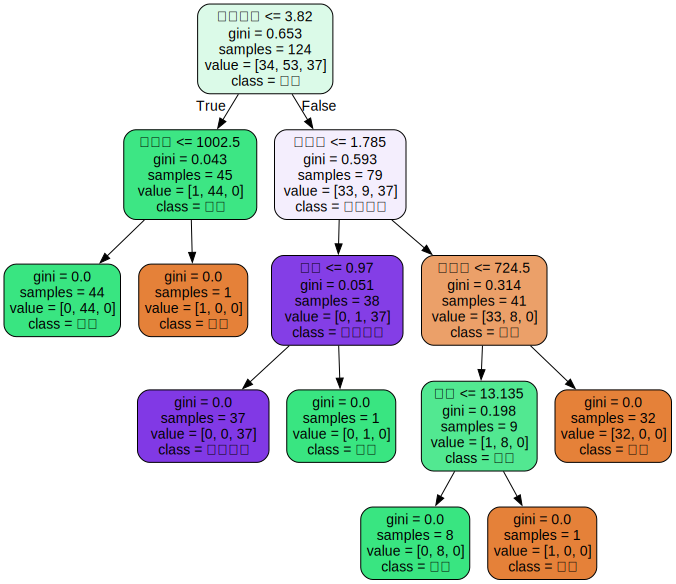

In [8]:
import graphviz

feature_name = ['酒精','苹果酸','灰','灰的碱性','镁','总酚','类黄酮','非黄烷类酚类','花青素','颜色强度','色调','od280/od315 稀释葡萄酒','脯氨酸']
dot_data = tree.export_graphviz(
    clf,
    out_file = None,
    feature_names = feature_name,
    class_names = ["琴酒","雪莉","贝尔摩德"],
    filled = True,
    rounded = True
)

graph = graphviz.Source(dot_data)
graph